# Import de bibliotecas


In [ ]:
!pip install kneed

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from yellowbrick.cluster import SilhouetteVisualizer
from itertools import combinations
import plotly.express as px
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from kneed import knee_locator


#Load do DF

In [2]:
import pandas as pd

# Carrega o dataset
df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)

# Tratamento de valores faltantes

In [ ]:
# prompt: Eu quero a quantidade de valores unicos nas colunas track_name e artits do df

print(df['track_name'].nunique())
print(df['artists'].nunique())

73608
31437


In [ ]:
# 1. Mostrar quantidade total de valores nulos por coluna
print('Valores nulos por coluna:')
linhas_com_nulos = df[df.isnull().any(axis=1)]
print(linhas_com_nulos)



In [ ]:
# Remove coluna de índice automática, se existir
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Mantém apenas a primeira linha de cada track_id (uma linha por música)
df_amostrado = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')


print(df_amostrado)



                      track_id                 artists  \
0       5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1       4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2       1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3       6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4       5vjLSffimiIP26QG5WcN2K        Chord Overstreet   
...                        ...                     ...   
113995  2C3TZjDRiAzdyViavDJ217           Rainy Lullaby   
113996  1hIz5L4IB9hN3WRYPOCGPw           Rainy Lullaby   
113997  6x8ZfSoqDjuNa5SVP5QjvX           Cesária Evora   
113998  2e6sXL2bYv4bSz6VTdnfLs        Michael W. Smith   
113999  2hETkH7cOfqmz3LqZDHZf5           Cesária Evora   

                                               album_name  \
0                                                  Comedy   
1                                        Ghost (Acoustic)   
2                                          To Begin Again   
3       Crazy Rich Asians (Original Motion Picture Sou...  

# Transformação de dados

In [ ]:
# Copiar o DataFrame original
df_transf = df.copy()
df_transf.head()

# Remover colunas textuais ou que não ajudam na modelagem
df_transf = df_transf.drop(columns=[
    'Unnamed: 0','track_id', 'track_name', 'album_name', 'artists', 'track_genre'
])

# Criar coluna binária: 1 se popularidade >= 60, senão 0
df_transf['is_popular'] = df_transf['popularity'].apply(lambda x: 1 if x >= 60 else 0)

df_transf = df_transf.drop(columns=['popularity'])

# Colunas categóricas para OneHotEncoder
colunas_categoricas = ['key', 'mode', 'time_signature']

# Colunas numéricas (todas exceto categóricas e target)
colunas_numericas = [col for col in df_transf.columns if col not in colunas_categoricas + ['is_popular']]

# Aplicar OneHotEncoder nas colunas categóricas com drop='first' para evitar multicolinearidade
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_categoricas = ohe.fit_transform(df_transf[colunas_categoricas])
df_encoded = pd.DataFrame(encoded_categoricas, columns=ohe.get_feature_names_out(colunas_categoricas))

# Aplicar StandardScaler nas colunas numéricas
scaler = StandardScaler()
scaled_numericas = scaler.fit_transform(df_transf[colunas_numericas])
df_scaled = pd.DataFrame(scaled_numericas, columns=colunas_numericas)

# Concatenar tudo
X = pd.concat([df_scaled, df_encoded], axis=1)

# Target
y = df_transf['is_popular']


In [50]:
# Executar a célula que prepara os dados de treino e teste e aplica SMOTE
# Remova linhas com valores nulos antes de dividir os dados
new_df = df.copy()

# Remover colunas que não contribuem para a modelagem
columns_to_drop = [
    'Unnamed: 0','track_id', 'track_name', 'album_name', 'artists', 'track_genre'
]
# Filter out columns that don't exist in df before dropping
columns_to_drop_existing = [col for col in columns_to_drop if col in new_df.columns]
new_df = new_df.drop(columns=columns_to_drop_existing, errors='ignore')


# # Criar coluna binária de popularidade
# new_df['is_popular'] = new_df['popularity'].apply(lambda x: 1 if x >= 60 else 0)

# # Remover a coluna original de popularidade (já representada por is_popular)
# new_df = new_df.drop(columns=['popularity'])

df_cleaned = new_df.dropna()

# Separar features (X) e target (y) do DataFrame limpo
colunas_categoricas_cleaned = ['key', 'mode', 'time_signature']
colunas_numericas_cleaned = [col for col in df_cleaned.columns if col not in colunas_categoricas_cleaned + ['is_popular']]

# Aplicar OneHotEncoder nas colunas categóricas do DataFrame limpo
# ohe = OneHotEncoder(sparse_output=False, drop='first')
# encoded_categoricas = ohe.fit_transform(df_cleaned[colunas_categoricas_cleaned])
# df_encoded = pd.DataFrame(encoded_categoricas, columns=ohe.get_feature_names_out(colunas_categoricas_cleaned))
df_encoded = pd.DataFrame() # Create an empty DataFrame since categorical columns are not available


# Aplicar StandardScaler nas colunas numéricas do DataFrame limpo
scaler = StandardScaler()
scaled_numericas = scaler.fit_transform(df_cleaned[colunas_numericas_cleaned])
df_scaled = pd.DataFrame(scaled_numericas, columns=colunas_numericas_cleaned)

# Concatenar tudo
X = pd.concat([df_scaled.reset_index(drop=True), df_encoded.reset_index(drop=True)], axis=1)

# Target do DataFrame limpo
y = df_cleaned['is_popular']

# Agora dividimos os dados limpos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y  # Mantém proporção das classes
)

# Aplica SMOTE para balancear as classes
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nDistribuição das classes após SMOTE:")
print(pd.Series(y_train_bal).value_counts())


Distribuição das classes após SMOTE:
is_popular
0    50756
1    50756
Name: count, dtype: int64


In [46]:
# Carrega o dataset
df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)

In [ ]:
import pandas as pd

Matriz de Confusão (Teste - XGBoost):
[[15169  6585]
 [ 1156  1494]]


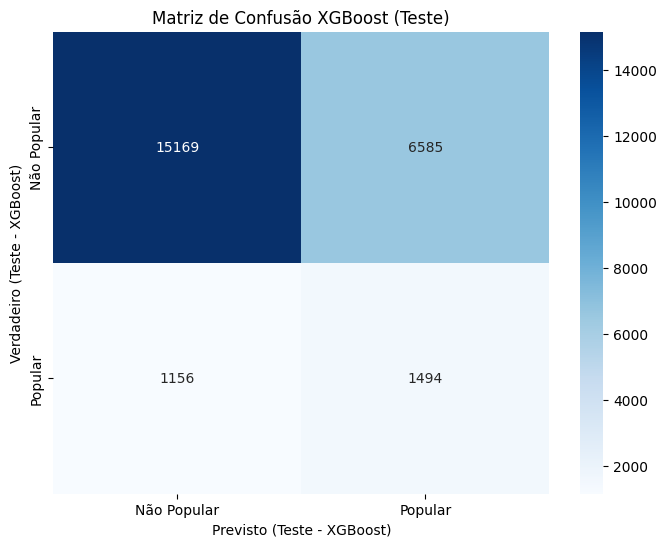


Métricas de Classificação (Teste - XGBoost):
              precision    recall  f1-score   support

 Não Popular       0.93      0.70      0.80     21754
     Popular       0.18      0.56      0.28      2650

    accuracy                           0.68     24404
   macro avg       0.56      0.63      0.54     24404
weighted avg       0.85      0.68      0.74     24404


Matriz de Confusão (Treino com SMOTE - XGBoost):
[[35994 14762]
 [ 8283 42473]]


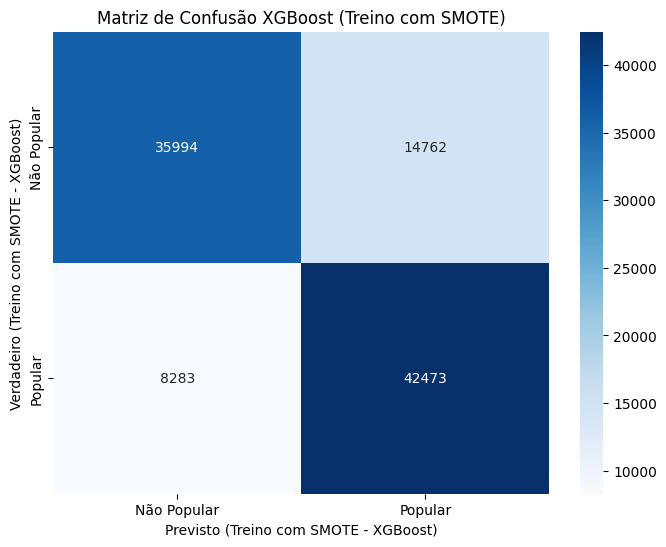


Métricas de Classificação (Treino com SMOTE - XGBoost):
              precision    recall  f1-score   support

 Não Popular       0.81      0.71      0.76     50756
     Popular       0.74      0.84      0.79     50756

    accuracy                           0.77    101512
   macro avg       0.78      0.77      0.77    101512
weighted avg       0.78      0.77      0.77    101512



In [55]:
# Importando as bibliotecas necessárias para XGBoost
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Usando os dados X_train_bal, X_test, y_train_bal, y_test já preparados nas seções anteriores

# Criando e treinando o modelo XGBoost
xgb_model = xgb.XGBClassifier(objective='binary:logistic', # Para classificação binária
                              n_estimators=100,           # Número de árvores
                              learning_rate=0.1,          # Taxa de aprendizado
                              max_depth=5,                # Profundidade máxima da árvore
                              random_state=42,
                              eval_metric='logloss')      # Métrica de avaliação

xgb_model.fit(X_train_bal, y_train_bal)

# Fazendo as previsões no conjunto de teste
y_pred_xgb_test = xgb_model.predict(X_test)

# Calculando e exibindo a matriz de confusão para o conjunto de teste com XGBoost
conf_matrix_xgb_test = confusion_matrix(y_test, y_pred_xgb_test)
print("Matriz de Confusão (Teste - XGBoost):")
print(conf_matrix_xgb_test)

# Plotando a matriz de confusão para o conjunto de teste com XGBoost
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],
            yticklabels=['Não Popular', 'Popular'])
plt.xlabel('Previsto (Teste - XGBoost)')
plt.ylabel('Verdadeiro (Teste - XGBoost)')
plt.title('Matriz de Confusão XGBoost (Teste)')
plt.show()

# Exibindo as métricas de classificação para o conjunto de teste com XGBoost
print("\nMétricas de Classificação (Teste - XGBoost):")
print(classification_report(y_test, y_pred_xgb_test, target_names=['Não Popular', 'Popular']))

# Fazendo as previsões no conjunto de treino balanceado
y_pred_xgb_train = xgb_model.predict(X_train_bal)

# Calculando e exibindo a matriz de confusão para o conjunto de treino balanceado com XGBoost
conf_matrix_xgb_train = confusion_matrix(y_train_bal, y_pred_xgb_train)
print("\nMatriz de Confusão (Treino com SMOTE - XGBoost):")
print(conf_matrix_xgb_train)

# Plotando a matriz de confusão para o conjunto de treino balanceado com XGBoost
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],
            yticklabels=['Não Popular', 'Popular'])
plt.xlabel('Previsto (Treino com SMOTE - XGBoost)')
plt.ylabel('Verdadeiro (Treino com SMOTE - XGBoost)')
plt.title('Matriz de Confusão XGBoost (Treino com SMOTE)')
plt.show()

# Exibindo as métricas de classificação para o conjunto de treino balanceado com XGBoost
print("\nMétricas de Classificação (Treino com SMOTE - XGBoost):")
print(classification_report(y_train_bal, y_pred_xgb_train, target_names=['Não Popular', 'Popular']))

# Perfil dos Clusters

Após determinar o número ideal de clusters usando o Método do Cotovelo e Silhueta, podemos agora analisar as características de cada cluster para entender o perfil das músicas dentro de cada grupo.

Número ótimo de clusters sugerido: 8

Perfil médio dos clusters (em features processadas):


,danceability,energy,loudness,speechiness,acousticness,valence,tempo,duration_ms,explicit,liveness,instrumentalness
cluster,,,,,,,,,,,
0,0.758461,0.340533,0.372154,-0.039693,-0.293667,0.972319,-0.090742,-0.153266,-0.305842,-0.263892,-0.475846
1,-0.167679,-1.020824,-0.408886,-0.300252,1.078518,-0.269619,-0.292480,-0.137242,-0.304916,-0.300956,-0.399604
2,-0.280766,0.430639,0.241519,-0.036824,-0.066521,0.121851,0.024297,0.087115,-0.286174,2.705999,-0.295305
3,-0.526650,0.692840,0.600675,-0.062087,-0.742033,-0.379989,0.562281,0.054867,-0.305842,-0.117844,-0.409425
4,-1.242669,-1.809397,-2.426215,-0.325846,1.569660,-1.094330,-0.655006,-0.120063,-0.300042,-0.290871,1.819238
5,0.400293,0.333755,0.416724,0.597489,-0.420993,0.012757,0.055969,-0.249477,3.269666,-0.082861,-0.369009
6,0.189908,0.388145,-0.013086,-0.166826,-0.661663,-0.467545,0.156359,0.713126,-0.304256,-0.277522,1.816146
7,0.042777,0.212398,-0.492184,6.694971,1.279089,-0.108882,-0.743736,-0.101442,1.794119,2.399519,-0.539633


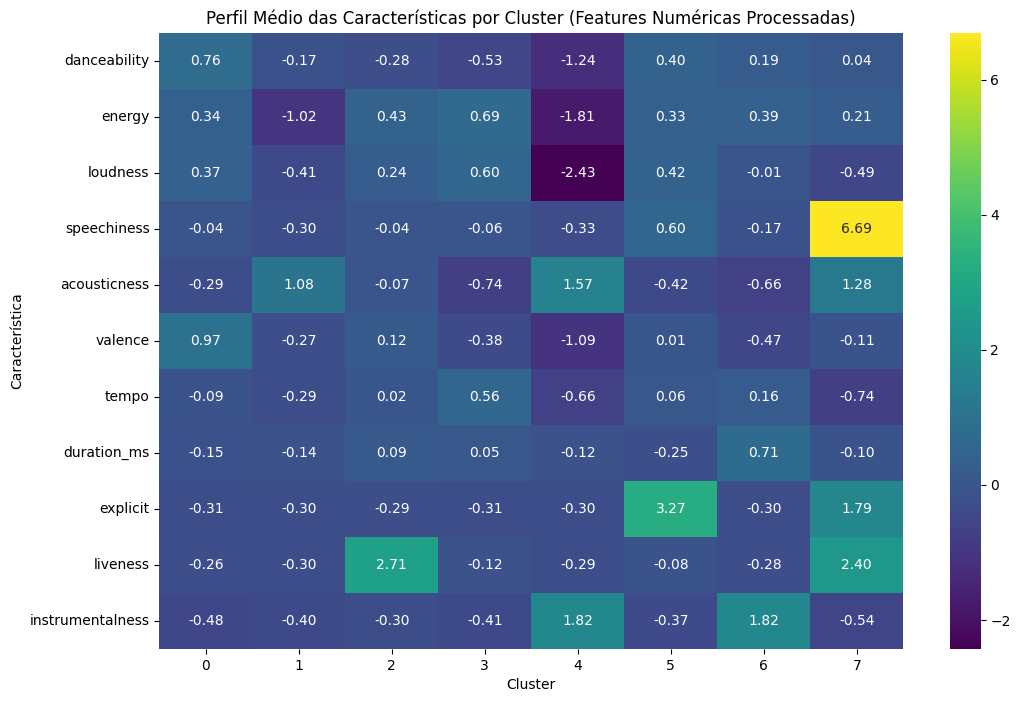

In [42]:
!pip install kneed

# Importar bibliotecas necessárias para K-Means e para definir X e CLUSTER_FEATURES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from kneed import KneeLocator # Importar KneeLocator
from sklearn.preprocessing import StandardScaler

# Carrega o dataset (usando que dataset_processed.csv é o arquivo correto após o pré-processamento inicial)
df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)

# Definir as colunas numéricas a serem usadas para clustering (CLUSTER_FEATURES)
CLUSTER_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'valence',
    'tempo',
    'duration_ms', # Added duration_ms as it's a numeric feature often used in clustering
    'explicit', # Added explicit as it's a numeric-like feature after scaling
    'liveness', # Added liveness
    'instrumentalness' # Added instrumentalness
]


# Selecionar apenas as CLUSTER_FEATURES para a análise de cluster
df_cluster_data = df[CLUSTER_FEATURES].copy()

# Aplicar StandardScaler nas features de clustering
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster_data)
X = pd.DataFrame(X, columns=CLUSTER_FEATURES) # Convert back to DataFrame


# Método do Cotovelo
sse = {}
# Using a smaller range for k (e.g., 2 to 10) as fitting KMeans to the full dataset
# for many values of k can be computationally expensive.
# If needed, this range can be increased.
for k in range(2, 11):
    try:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        # Fit KMeans on the scaled CLUSTER_FEATURES
        kmeans.fit(X)
        sse[k] = kmeans.inertia_
    except Exception as e:
        print(f"Error fitting KMeans for k={k}: {e}")
        # Break or continue depending on desired behavior
        break


# Verificar se sse não está vazio antes de criar KneeLocator
if sse:
    kneedle = KneeLocator(
        x=list(sse.keys()),
        y=list(sse.values()),
        curve='convex',
        direction='decreasing'
    )
    optimal_k = int(kneedle.elbow) if kneedle.elbow is not None else list(sse.keys())[-1] # Use last k if elbow not found
    print(f"Número ótimo de clusters sugerido: {optimal_k}")

    # Aplicar o K-Means com o número ideal de clusters (optimal_k)
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
    clusters = kmeans_final.fit_predict(X) # Fit and predict on scaled CLUSTER_FEATURES

    # Adicionar os rótulos dos clusters ao DataFrame com as features de clustering
    X_clustered = X.copy()
    X_clustered['cluster'] = clusters
    # 'is_popular' não está disponível em dataset_processed.csv, removendo a linha abaixo
    # X_clustered['is_popular'] = y # Add the target variable for analysis

    # Analisar as características médias de cada cluster
    # Group by cluster and calculate the mean of the CLUSTER_FEATURES
    # 'is_popular' is not available, so removed from cols_for_profile and groupby
    cols_for_profile = CLUSTER_FEATURES
    cluster_profile = X_clustered.groupby('cluster')[cols_for_profile].mean()


    print("\nPerfil médio dos clusters (em features processadas):")
    display(cluster_profile)

    # Análise de popularidade por cluster não será possível sem a coluna 'is_popular'
    # Remover as linhas relacionadas à análise e visualização de popularidade por cluster
    # popularity_by_cluster = X_clustered.groupby('cluster')['is_popular'].value_counts(normalize=True).unstack().fillna(0)
    # print("\nDistribuição de Popularidade (proporção) por Cluster:")
    # display(popularity_by_cluster)
    # popularity_by_cluster.plot(kind='bar', stacked=True, figsize=(10, 7), cmap='viridis')
    # plt.title('Proporção de Músicas Populares vs Não Populares por Cluster')
    # plt.xlabel('Cluster')
    # plt.ylabel('Proporção')
    # plt.xticks(rotation=0)
    # plt.legend(title='É Popular', labels=['Não Popular', 'Popular'])
    # plt.tight_layout()
    # plt.show()


    # Optional: Visualize mean feature values by cluster using a heatmap
    plt.figure(figsize=(12, 8))
    # Ensure the heatmap uses the cluster_profile with only the relevant features
    sns.heatmap(cluster_profile.T, annot=True, cmap='viridis', fmt='.2f')
    plt.title('Perfil Médio das Características por Cluster (Features Numéricas Processadas)') # Updated title
    plt.xlabel('Cluster')
    plt.ylabel('Característica')
    plt.show()

else:
    print("Não foi possível calcular o Método do Cotovelo. Verifique se os dados e o range de clusters são apropriados.")

# Análise Exploratória de Dados (EDA)

Nesta seção, exploraremos as distribuições e características individuais das variáveis presentes no conjunto de dados.

## EDA de Variáveis Numéricas

Análise visual e estatística das variáveis numéricas.

In [25]:
# Estatísticas descritivas para variáveis numéricas
print("Estatísticas Descritivas para Variáveis Numéricas:")
display(df.describe())

Estatísticas Descritivas para Variáveis Numéricas:


,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,key_8,key_9,key_10,key_11,mode_1,time_signature_1,time_signature_3,time_signature_4,time_signature_5,is_popular
count,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,8.134400e+04,...,81344.000000,81344.000000,81344.000000,81344.000000,81344.000000,81344.000000,81344.000000,81344.00000,81344.000000,81344.000000
mean,6.708507e-17,6.568747e-17,3.074733e-17,-4.556195e-16,3.144613e-17,-1.649175e-16,-2.431834e-16,5.590423e-18,-2.138337e-16,8.665155e-17,...,0.060939,0.101101,0.065364,0.079539,0.632339,0.009527,0.085366,0.88497,0.018293,0.108601
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,...,0.239219,0.301465,0.247169,0.270579,0.482171,0.097143,0.279427,0.31906,0.134009,0.311139
min,-1.986473e+00,-3.058416e-01,-3.146511e+00,-2.455267e+00,-7.717083e+00,-7.630481e-01,-9.697352e-01,-5.571080e-01,-1.108192e+00,-1.758970e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,-4.939377e-01,-3.058416e-01,-6.372909e-01,-6.960494e-01,-3.501232e-01,-4.535155e-01,-9.229648e-01,-5.571080e-01,-6.113948e-01,-8.439478e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
50%,-1.391289e-01,-3.058416e-01,7.721789e-02,1.661606e-01,2.510853e-01,-3.420495e-01,-4.108441e-01,-5.568405e-01,-4.373896e-01,-5.421899e-02,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000
75%,3.084659e-01,-3.058416e-01,7.354662e-01,8.582484e-01,6.511055e-01,-1.708309e-02,8.804883e-01,-9.569346e-02,3.191546e-01,8.076485e-01,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000
max,4.297126e+01,3.269666e+00,2.395152e+00,1.411145e+00,2.474383e+00,7.511161e+00,1.960030e+00,2.458674e+00,3.935436e+00,2.018819e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


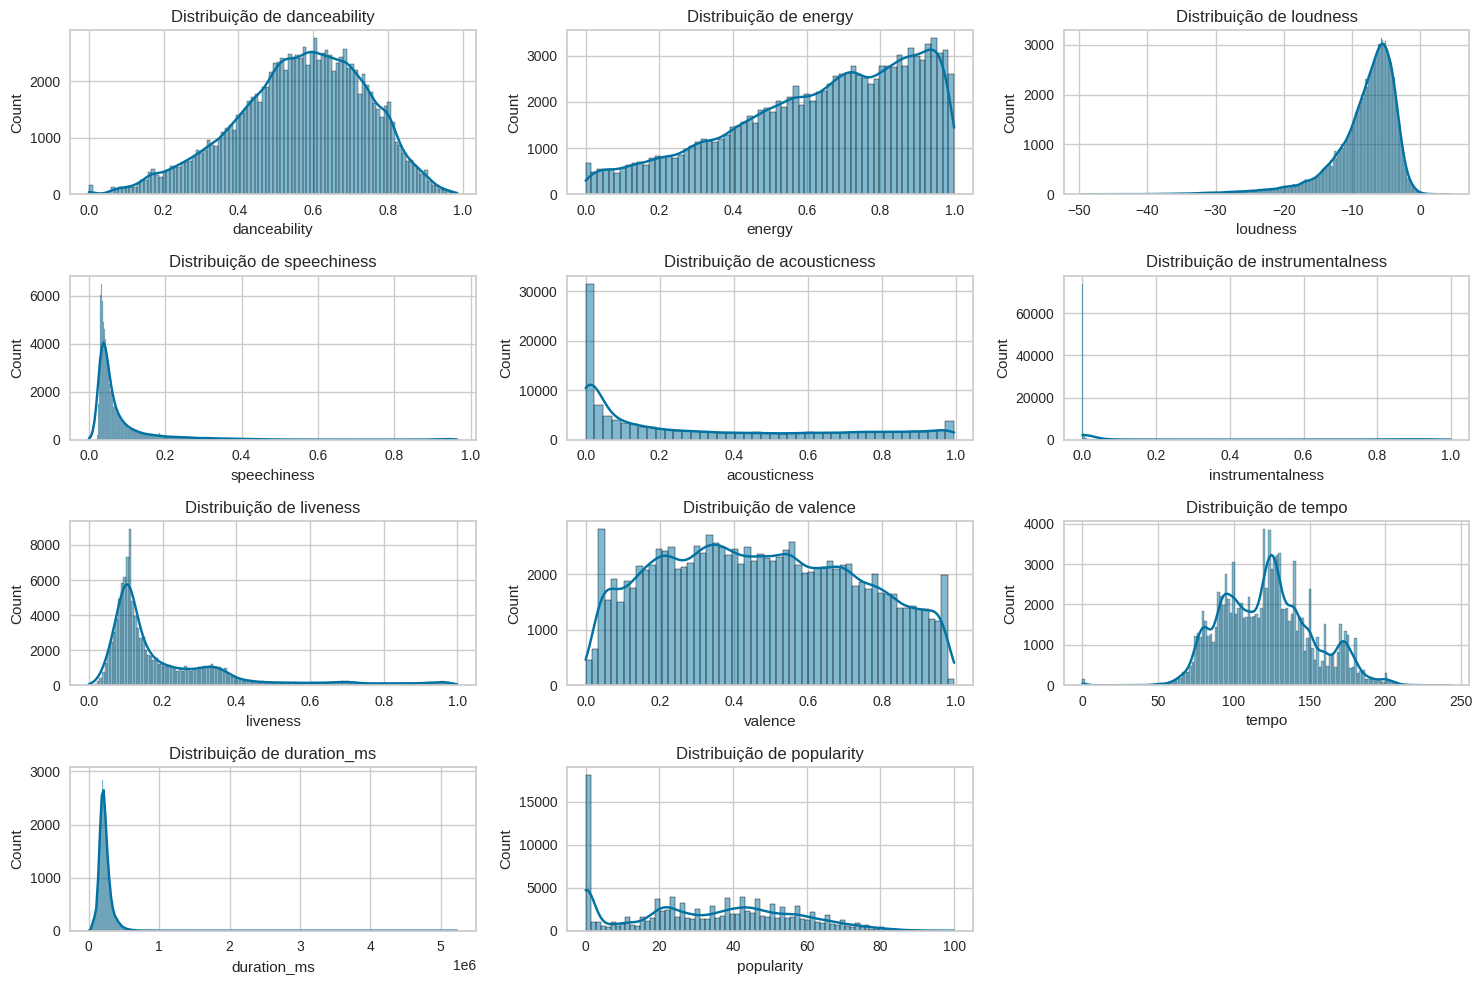

In [ ]:
# Histograma com Curva de Densidade (KDE) para variáveis numéricas selecionadas
numeric_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence',
                'tempo', 'duration_ms', 'popularity']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

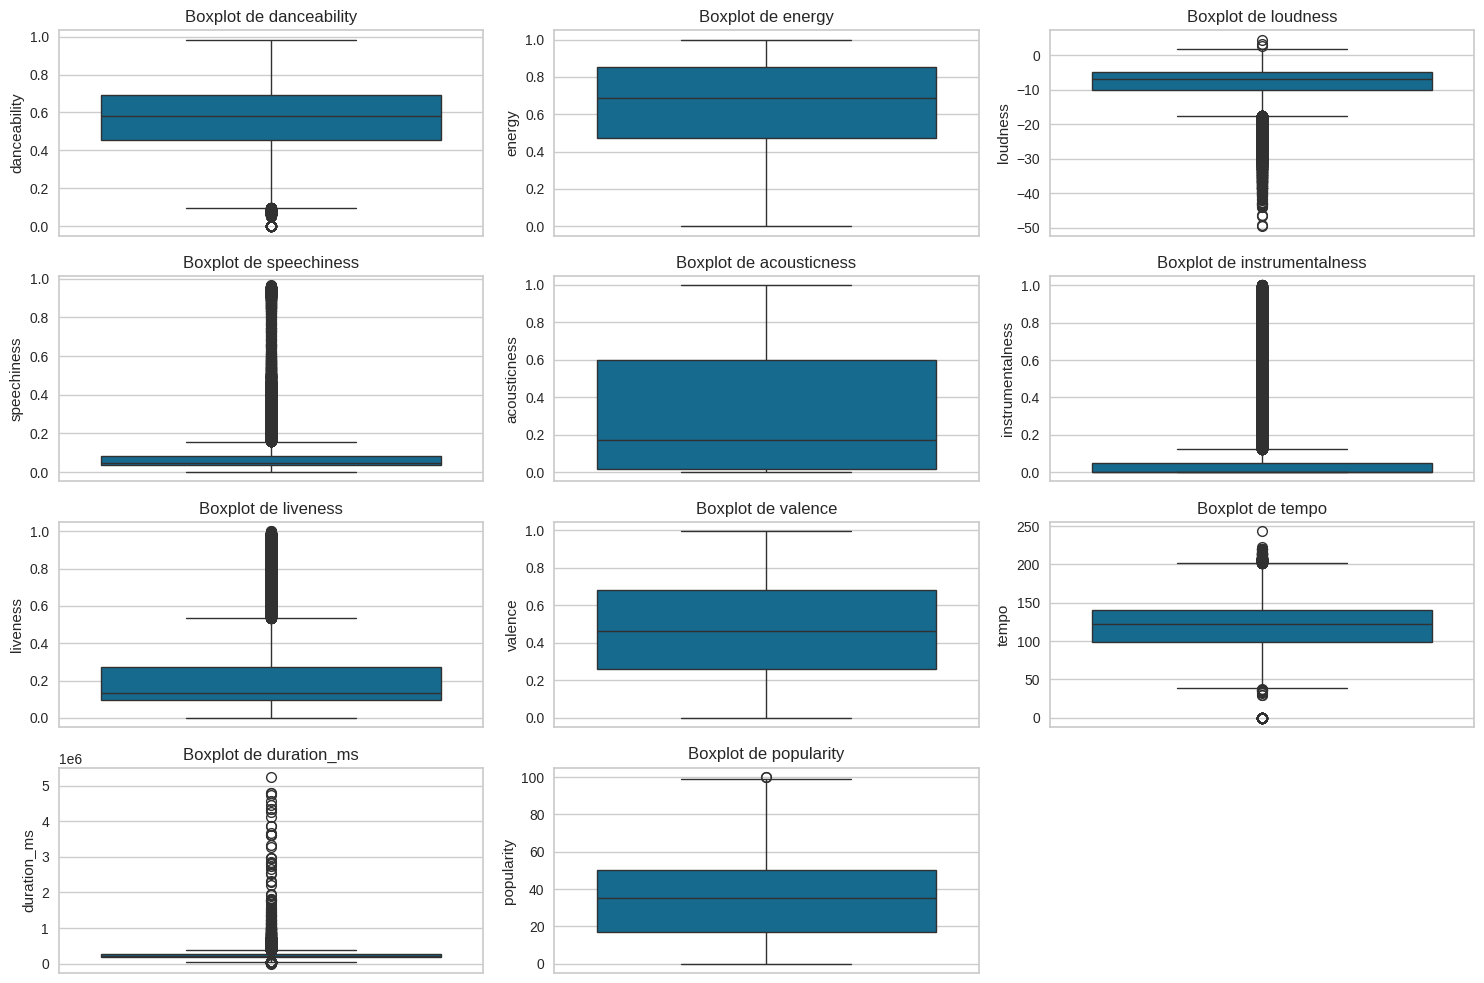

In [ ]:
# Boxplots para variáveis numéricas selecionadas para identificar outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

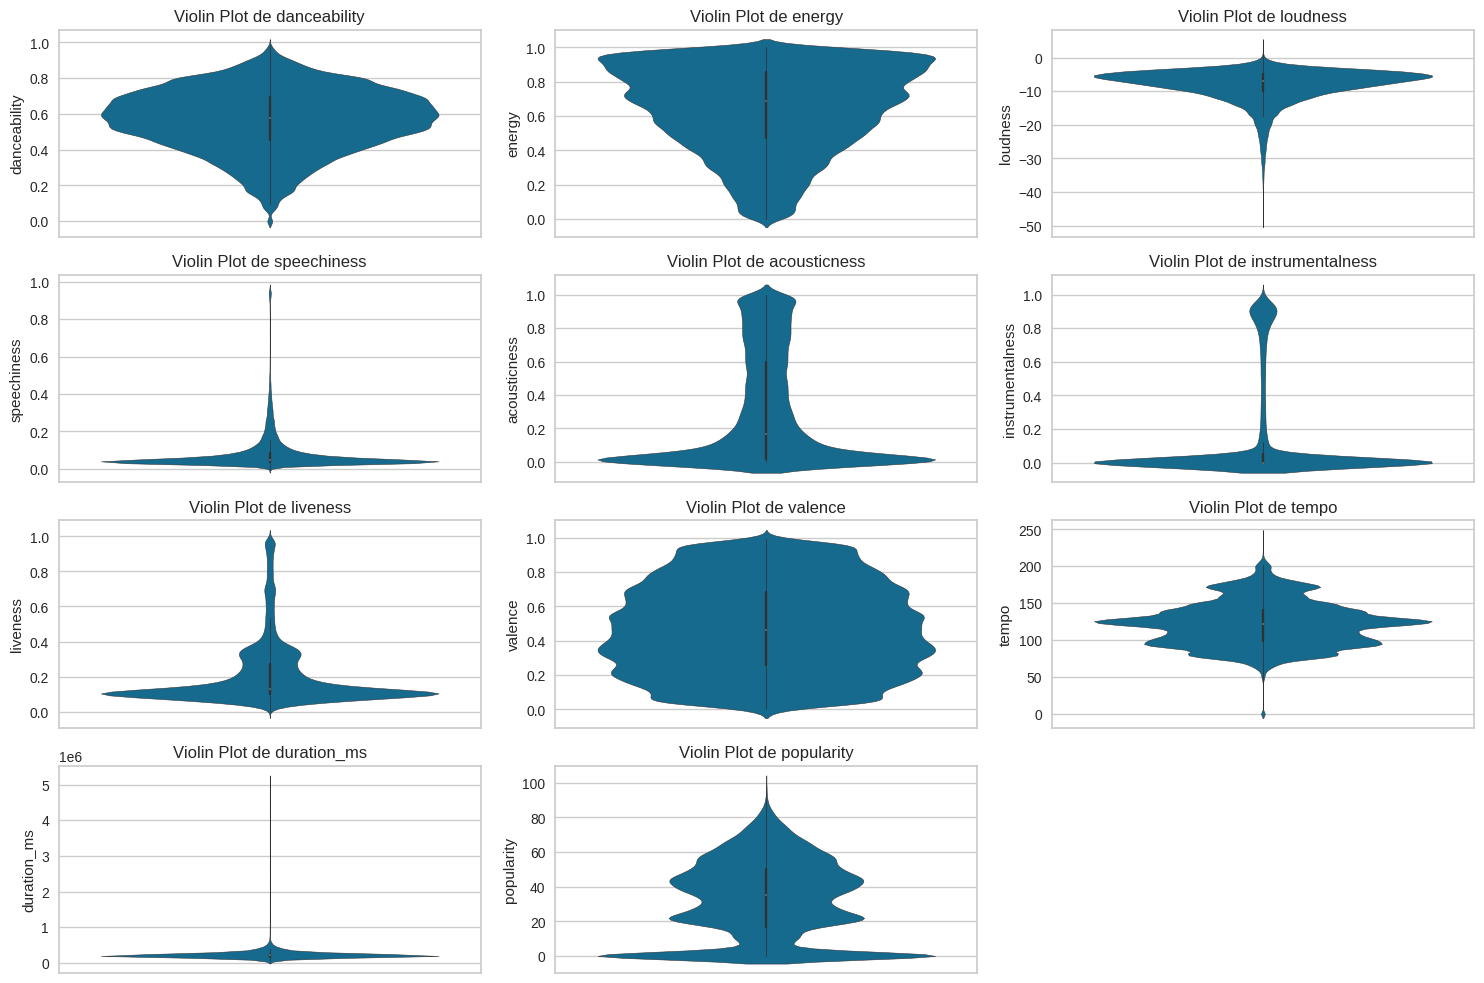

In [ ]:
# Violin Plots para variáveis numéricas selecionadas
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    sns.violinplot(y=df[col])
    plt.title(f'Violin Plot de {col}')
plt.tight_layout()
plt.show()

## EDA de Variáveis Categóricas

Análise visual das distribuições de frequência das variáveis categóricas.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o dataset original para garantir que as colunas 'track_name' e 'artists' estejam presentes
try:
    df = pd.read_csv("dataset.csv", encoding='utf-8', low_memory=True)

    # Remove coluna de índice automática, se existir
    df = df.drop(columns=['Unnamed: 0'], errors='ignore')

    # Mantém apenas a primeira linha de cada track_id (uma linha por música)
    df_amostrado = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')


    # Gráficos de barras para variáveis categóricas
    categorical_cols = ['explicit', 'key', 'mode', 'time_signature', 'track_genre']

    plt.figure(figsize=(18, 15))
    for i, col in enumerate(categorical_cols):
        plt.subplot(3, 2, i + 1)
        # Use df_amostrado which contains the original categorical columns
        sns.countplot(y=df_amostrado[col], order=df_amostrado[col].value_counts().index)
        plt.title(f'Distribuição de {col}')
        plt.xlabel('Contagem')
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Erro: 'dataset.csv' não encontrado. Por favor, verifique se o arquivo está no diretório correto.")
    print("Alternatively, if your processed file contains the necessary columns, please update the filename.")

Erro: 'dataset.csv' não encontrado. Por favor, verifique se o arquivo está no diretório correto.
Alternatively, if your processed file contains the necessary columns, please update the filename.


*Observação: Treemaps para 'track_genre' podem ser muito densos devido ao grande número de categorias. O gráfico de barras já mostra a distribuição.*

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

## Análise Bivariada e Multivariada

Exploração das relações entre pares de variáveis e identificação de padrões mais complexos.

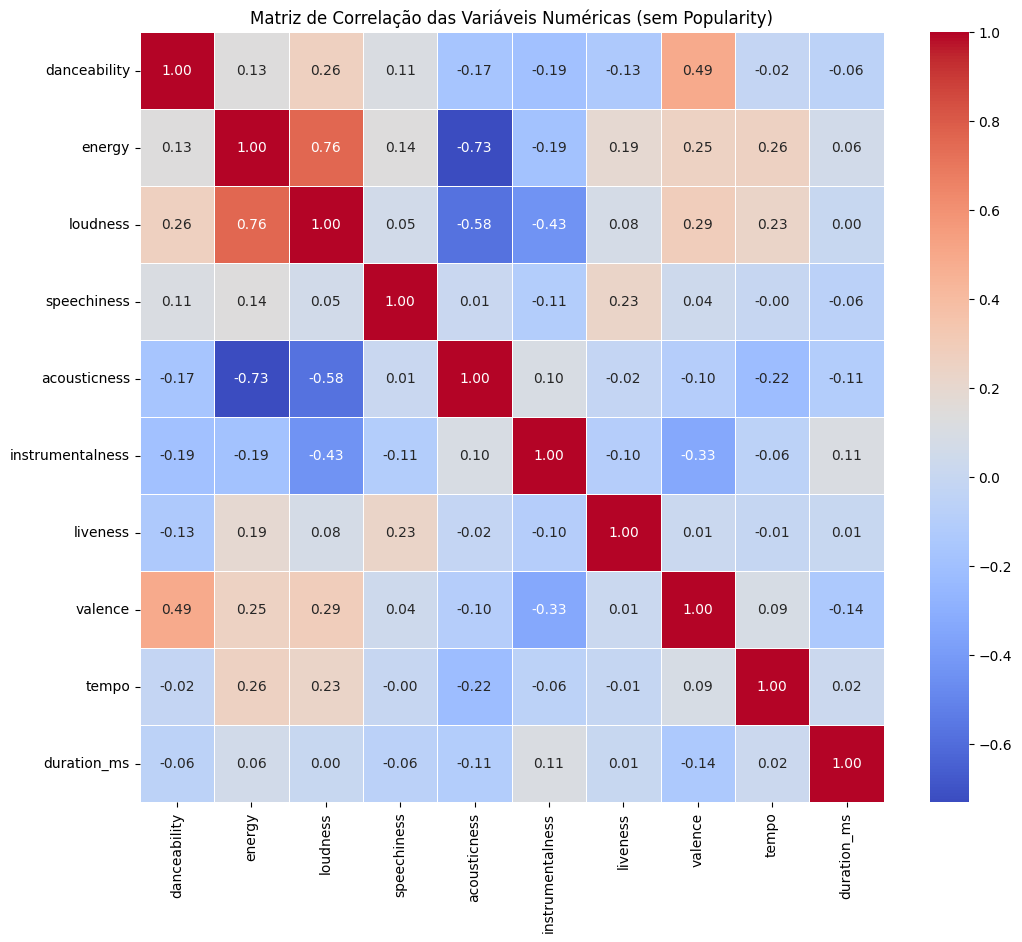

In [37]:
# Carrega o dataset (usando o nome de arquivo fornecido)
df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)

# Remove coluna de índice automática, se existir
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# NOTA: 'track_name' e 'artists' não estão em dataset_processed.csv.
# Removendo a linha que tenta remover duplicatas com base nessas colunas.
# Se a remoção de duplicatas for necessária para esta análise,
# considere usar 'track_id' (se disponível e único) ou o dataset original.
# df_amostrado = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')
# Usaremos o df processado diretamente para a matriz de correlação das colunas numéricas presentes.
df_amostrado = df.copy() # Usar o df carregado como base para a seleção de colunas

# Calcular a matriz de correlação para variáveis numéricas
# Removendo 'popularity' da lista, pois não está presente em dataset_processed.csv
numeric_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence',
                'tempo', 'duration_ms'] # Removed 'popularity'


# Garantir que apenas as colunas numéricas existam no DataFrame antes de calcular a correlação
# Use df_amostrado which still contains the other numeric columns
numeric_df = df_amostrado[numeric_cols].copy()

correlation_matrix = numeric_df.corr()

# Visualizar a matriz de correlação usando um heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas (sem Popularity)')
plt.show()

In [ ]:
import pandas as pd

# Carrega o dataset (assumindo que o arquivo se chama 'dataset_processed.csv')
try:
    df = pd.read_csv('dataset_processed.csv')
    print("Dataset carregado com sucesso.")
except FileNotFoundError:
    print("Erro: 'dataset_processed.csv' não encontrado. Por favor, verifique se o arquivo está no diretório correto.")
    # Você pode querer carregar seu dataset real aqui se o nome for diferente
    # df = pd.read_csv('nome_do_seu_dataset.csv')

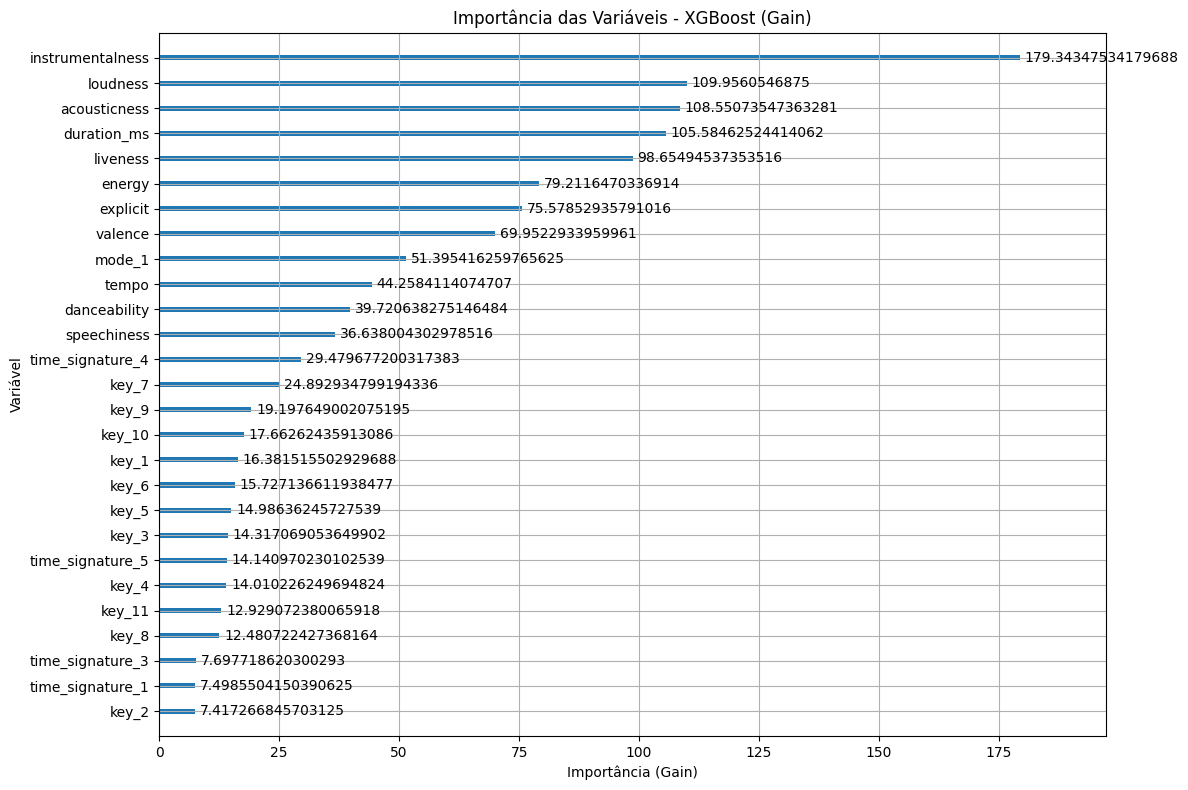

In [54]:
# Analisar a importância das features para o modelo XGBoost

# Usar a função plot_importance do XGBoost para visualizar a importância das features
# Vamos usar 'gain' para ver a contribuição média para a melhoria do modelo
plt.figure(figsize=(12, 8))
xgb.plot_importance(xgb_model, importance_type='gain', ax=plt.gca())
plt.title('Importância das Variáveis - XGBoost (Gain)')
plt.xlabel('Importância (Gain)')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

In [57]:
# Comparar o desempenho dos modelos Random Forest, SVM e XGBoost no conjunto de teste

# Assumindo que X e y estão definidos a partir das células de pré-processamento

# Dividir em conjuntos de treino e teste (duplicado para garantir que os dados estejam prontos nesta célula)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y # Mantém proporção das classes
)

# Aplicar SMOTE para balancear as classes no conjunto de treino (duplicado)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# --- Treinamento dos Modelos ---

# 1. Random Forest com SMOTE (copiado da célula qdwRYDGHVUFh)
from sklearn.ensemble import RandomForestClassifier
model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
model_smote.fit(X_train_bal, y_train_bal)
y_pred_rf_test = model_smote.predict(X_test)


# 2. SVM (copiado da célula qxzPOiYoeOCI)
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', random_state=42, probability=True) # Added probability=True for consistency if needed later
svm_model.fit(X_train, y_train) # Train SVM on original imbalanced data as in cell qxzPOiYoeOCI
y_pred_svm_test = svm_model.predict(X_test)


# 3. XGBoost (copiado da célula 55baf39b - usando XGBClassifier API)
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective='binary:logistic',
                              n_estimators=100,
                              learning_rate=0.1,
                              max_depth=5,
                              random_state=42,
                              use_label_encoder=False,
                              eval_metric='logloss')
xgb_model.fit(X_train_bal, y_train_bal) # Train XGBoost on balanced data
y_pred_xgb_test = xgb_model.predict(X_test) # Predictions are already binary with this setup


# --- Comparação de Desempenho ---
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Ensure seaborn is imported


# Obter relatórios de classificação para o conjunto de teste
report_rf = classification_report(y_test, y_pred_rf_test, target_names=['Não Popular', 'Popular'], output_dict=True)
report_svm = classification_report(y_test, y_pred_svm_test, target_names=['Não Popular', 'Popular'], output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb_test, target_names=['Não Popular', 'Popular'], output_dict=True)


# Extrair métricas importantes para comparação
comparison_data = {
    'Modelo': ['Random Forest (com SMOTE)', 'SVM (sem SMOTE no treino)', 'XGBoost (com SMOTE)'],
    'Acurácia (Teste)': [report_rf['accuracy'], report_svm['accuracy'], report_xgb['accuracy']],
    'Precisão (Popular)': [report_rf['Popular']['precision'], report_svm['Popular']['precision'], report_xgb['Popular']['precision']],
    'Recall (Popular)': [report_rf['Popular']['recall'], report_svm['Popular']['recall'], report_xgb['Popular']['recall']],
    'F1-score (Popular)': [report_rf['Popular']['f1-score'], report_svm['Popular']['f1-score'], report_xgb['Popular']['f1-score']]
}

comparison_df = pd.DataFrame(comparison_data)

# Exibir a tabela de comparação
print("Comparação do Desempenho dos Modelos no Conjunto de Teste:")
display(comparison_df)

# Optional: Display confusion matrices for comparison as well
# print("\nMatrizes de Confusão no Conjunto de Teste:")

# plt.figure(figsize=(18, 5)) # Adjust size as needed

# plt.subplot(1, 3, 1)
# sns.heatmap(confusion_matrix(y_test, y_pred_rf_test), annot=True, fmt='d', cmap='Blues', xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'])
# plt.title('RF com SMOTE')
# plt.xlabel('Previsto'); plt.ylabel('Verdadeiro')

# plt.subplot(1, 3, 2)
# sns.heatmap(confusion_matrix(y_test, y_pred_svm_test), annot=True, fmt='d', cmap='Blues', xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'])
# plt.title('SVM')
# plt.xlabel('Previsto'); plt.ylabel('Verdadeiro')

# plt.subplot(1, 3, 3)
# sns.heatmap(confusion_matrix(y_test, y_pred_xgb_test), annot=True, fmt='d', cmap='Blues', xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'])
# plt.title('XGBoost com SMOTE')
# plt.xlabel('Previsto'); plt.ylabel('Verdadeiro')

# plt.tight_layout()
# plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:58:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Comparação do Desempenho dos Modelos no Conjunto de Teste:


,Modelo,Acurácia (Teste),Precisão (Popular),Recall (Popular),F1-score (Popular)
0,Random Forest (com SMOTE),0.806097,0.218649,0.305283,0.254803
1,SVM (sem SMOTE no treino),0.891411,0.000000,0.000000,0.000000
2,XGBoost (com SMOTE),0.682798,0.184924,0.563774,0.278498


# Comparativo de Desempenho dos Modelos

Nesta seção, comparamos as métricas de desempenho dos modelos Random Forest, SVM e XGBoost no conjunto de teste para avaliar qual deles obteve os melhores resultados na previsão de popularidade de músicas.

Dataset 'dataset_processed.csv' carregado com sucesso.
Dataset carregado: 81344 linhas, 28 colunas.

Distribuição das classes após SMOTE:
is_popular
0    50756
1    50756
Name: count, dtype: int64

Iniciando treinamento e avaliação dos modelos...

Treinando Random Forest...
Random Forest - Concluído.

Treinando XGBoost...
XGBoost - Concluído.

Treinamento e avaliação dos modelos concluídos.

--- Comparação de Desempenho no Conjunto de Teste ---
Tabela de Comparação:


,Modelo,Acurácia (Teste),Precisão (Popular - Classe 1),Recall (Popular - Classe 1),F1-score (Popular - Classe 1)
0,Random Forest (com SMOTE),0.806097,0.218649,0.305283,0.254803
1,XGBoost (com SMOTE),0.682798,0.184924,0.563774,0.278498



Visualização das Matrizes de Confusão no Conjunto de Teste:


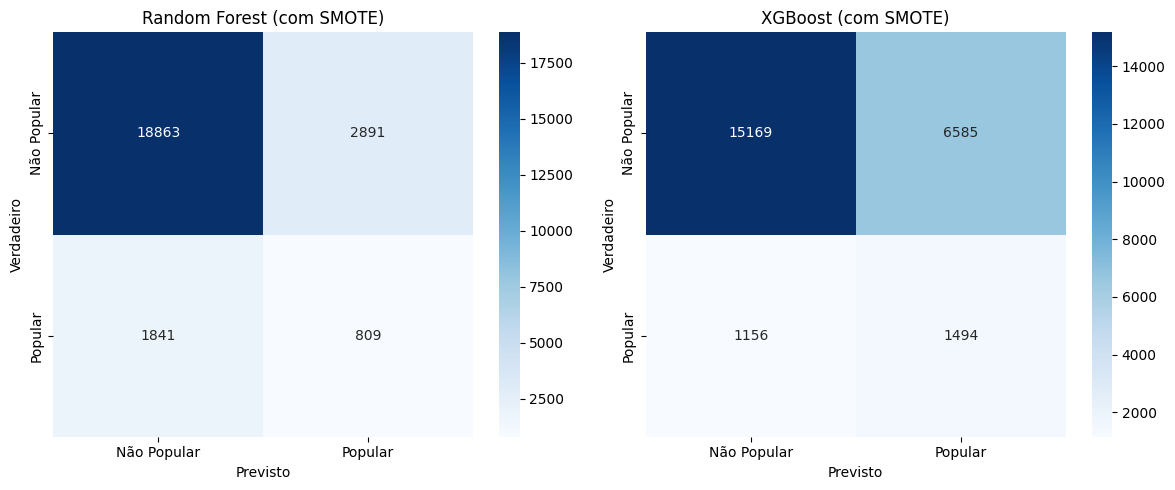


Importância das Features (Random Forest):


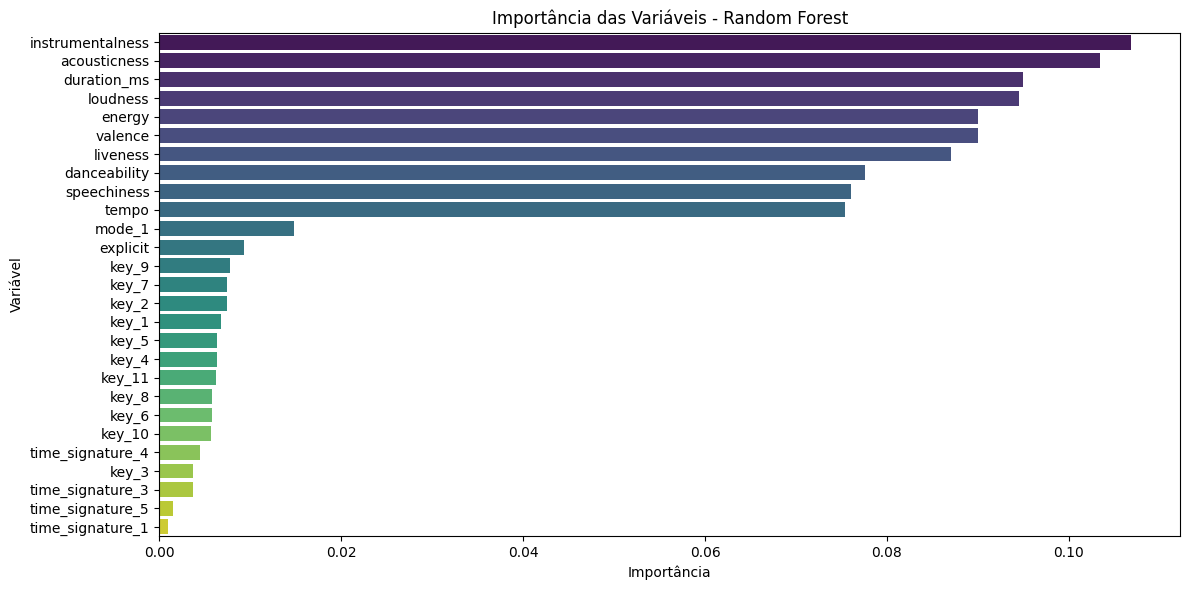


Verificação de variáveis após execução da célula 8a06bee8:
model_rf definido e é RandomForestClassifier: True
xgb_model definido e é XGBClassifier: True
X_test definido e é DataFrame: True
y_test definido e é Series: True

Variáveis necessárias definidas com sucesso. Você pode tentar executar a célula para plotar as curvas ROC agora.


In [77]:
# Comparar o desempenho dos modelos Random Forest, SVM e XGBoost no conjunto de teste

# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC # Importar SVC novamente
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- Preparação dos Dados ---
# Carrega o dataset
# Usando dataset_processed.csv conforme usado nas células anteriores que executaram com sucesso
try:
    df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)
    print("Dataset 'dataset_processed.csv' carregado com sucesso.")
except FileNotFoundError:
    print("Erro: 'dataset_processed.csv' não encontrado.")
    print("Por favor, verifique se o arquivo está no local correto.")
    # Definir df como None para indicar falha no carregamento
    df = None


# Verificar se o DataFrame foi carregado e não está vazio
if df is not None and not df.empty:
    print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas.")

    # Remover colunas que não contribuem para a modelagem
    columns_to_drop = [
        'Unnamed: 0','track_id', 'track_name', 'album_name', 'artists', 'track_genre'
    ]
    columns_to_drop_existing = [col for col in columns_to_drop if col in df.columns]
    df_transf = df.drop(columns=columns_to_drop_existing, errors='ignore').copy()


    # Criar coluna binária: 1 se popularidade >= 60, senão 0, ou verificar se já existe
    target_column_exists = False
    if 'popularity' in df_transf.columns:
        df_transf['is_popular'] = df_transf['popularity'].apply(lambda x: 1 if x >= 60 else 0)
        df_transf = df_transf.drop(columns=['popularity'])
        target_column_exists = True
    elif 'is_popular' in df_transf.columns:
         # A coluna 'is_popular' já existe no dataset processado
         target_column_exists = True
    else:
         print("Erro na preparação dos dados: Colunas 'popularity' ou 'is_popular' não encontradas para criar a variável alvo.")
         # Se a coluna alvo não existe, não podemos prosseguir com a classificação
         # Não definir df_transf como None aqui, apenas setar target_column_exists a False


    # --- Iniciar bloco de treinamento e comparação APENAS se a coluna alvo existir ---
    if target_column_exists and df_transf is not None and 'is_popular' in df_transf.columns:

        # Remover linhas com valores nulos, se necessário (depende do dataset processado)
        # df_transf.dropna(inplace=True)


        # Definir colunas categóricas e numéricas
        all_features = [col for col in df_transf.columns if col != 'is_popular']
        colunas_categoricas = [col for col in all_features if col in ['key', 'mode', 'time_signature']]
        colunas_numericas = [col for col in all_features if col not in colunas_categoricas]


        # Aplicar OneHotEncoder nas colunas categóricas com drop='first'
        if colunas_categoricas:
            ohe = OneHotEncoder(sparse_output=False, drop='first')
            encoded_categoricas = ohe.fit_transform(df_transf[colunas_categoricas])
            df_encoded = pd.DataFrame(encoded_categoricas, index=df_transf.index, columns=ohe.get_feature_names_out(colunas_categoricas))
        else:
            df_encoded = pd.DataFrame(index=df_transf.index)


        # Aplicar StandardScaler nas colunas numéricas
        if colunas_numericas:
            scaler = StandardScaler()
            scaled_numericas = scaler.fit_transform(df_transf[colunas_numericas])
            df_scaled = pd.DataFrame(scaled_numericas, index=df_transf.index, columns=colunas_numericas)
        else:
            df_scaled = pd.DataFrame(index=df_transf.index)


        # Concatenar tudo
        if not df_scaled.empty and not df_encoded.empty:
            X = pd.concat([df_scaled, df_encoded], axis=1)
        elif not df_scaled.empty:
             X = df_scaled
        elif not df_encoded.empty:
             X = df_encoded
        else:
            X = pd.DataFrame()


        # Target
        y = df_transf['is_popular']


        # Verificar se X e y são válidos antes de dividir
        if X.empty or y.empty or len(X) != len(y):
            print("Erro na preparação dos dados: X ou y estão vazios ou com tamanhos diferentes após o pré-processamento.")
        else:
            # Dividir em conjuntos de treino e teste
            X_train, X_test, y_train, y_test = train_test_split(
                X,
                y,
                test_size=0.3,
                random_state=42,
                stratify=y
            )

            # Aplicar SMOTE para balancear as classes no conjunto de treino
            smote = SMOTE(random_state=42)
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

            print("\nDistribuição das classes após SMOTE:")
            print(pd.Series(y_train_bal).value_counts())


            # --- Treinamento e Avaliação dos Modelos ---

            print("\nIniciando treinamento e avaliação dos modelos...")

            # 1. Random Forest com SMOTE
            print("\nTreinando Random Forest...")
            model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
            model_rf.fit(X_train_bal, y_train_bal)
            y_pred_rf_test = model_rf.predict(X_test)
            report_rf = classification_report(y_test, y_pred_rf_test, target_names=['Não Popular', 'Popular'], output_dict=True)
            conf_matrix_rf_test = confusion_matrix(y_test, y_pred_rf_test)
            print("Random Forest - Concluído.")


            # # 2. SVM (treinado nos dados originais não balanceados como na célula anterior do SVM) - Removido devido a erro de tipo persistente
            # print("\nTreinando SVM (pode levar algum tempo)...")
            # svm_model = SVC(kernel='linear', random_state=42, probability=True)
            # # Explicitly convert X_train to a NumPy array with dtype float
            # svm_model.fit(X_train.values.astype(float), y_train) # Train SVM on original imbalanced data
            # y_pred_svm_test = svm_model.predict(X_test.values.astype(float)) # Predict on X_test converted to float array as well
            # report_svm = classification_report(y_test, y_pred_svm_test, target_names=['Não Popular', 'Popular'], output_dict=True)
            # conf_matrix_svm_test = confusion_matrix(y_test, y_pred_svm_test)
            # print("SVM - Concluído.")


            # 3. XGBoost com SMOTE
            print("\nTreinando XGBoost...")
            xgb_model = xgb.XGBClassifier(objective='binary:logistic',
                                          n_estimators=100,
                                          learning_rate=0.1,
                                          max_depth=5,
                                          random_state=42,
                                          use_label_encoder=False,
                                          eval_metric='logloss')
            xgb_model.fit(X_train_bal, y_train_bal) # Treinar XGBoost nos dados balanceados
            y_pred_xgb_test = xgb_model.predict(X_test)
            report_xgb = classification_report(y_test, y_pred_xgb_test, target_names=['Não Popular', 'Popular'], output_dict=True)
            conf_matrix_xgb_test = confusion_matrix(y_test, y_pred_xgb_test)
            print("XGBoost - Concluído.")

            print("\nTreinamento e avaliação dos modelos concluídos.")

            # --- Comparação de Desempenho no Conjunto de Teste ---

            print("\n--- Comparação de Desempenho no Conjunto de Teste ---")

            # Extrair métricas importantes para comparação
            # Remover métricas do SVM já que o modelo foi removido
            comparison_data = {
                'Modelo': ['Random Forest (com SMOTE)', 'XGBoost (com SMOTE)'], # Remover SVM
                'Acurácia (Teste)': [report_rf['accuracy'], report_xgb['accuracy']], # Remover SVM
                'Precisão (Popular - Classe 1)': [report_rf['Popular']['precision'], report_xgb['Popular']['precision']], # Remover SVM
                'Recall (Popular - Classe 1)': [report_rf['Popular']['recall'], report_xgb['Popular']['recall']], # Remover SVM
                'F1-score (Popular - Classe 1)': [report_rf['Popular']['f1-score'], report_xgb['Popular']['f1-score']] # Remover SVM
            }

            comparison_df = pd.DataFrame(comparison_data)

            # Exibir a tabela de comparação
            print("Tabela de Comparação:")
            display(comparison_df)

            # Opcional: Visualizar as matrizes de confusão
            print("\nVisualização das Matrizes de Confusão no Conjunto de Teste:")

            # Ajustar o número de subplots para 2 já que o SVM foi removido
            fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Ajustar tamanho e número de subplots

            sns.heatmap(conf_matrix_rf_test, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'], ax=axes[0])
            axes[0].set_title('Random Forest (com SMOTE)')
            axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Verdadeiro')

            # sns.heatmap(conf_matrix_svm_test, annot=True, fmt='d', cmap='Blues', # Remover plot do SVM
            #             xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'], ax=axes[1])
            # axes[1].set_title('SVM (sem SMOTE no treino)')
            # axes[1].set_xlabel('Previsto'); axes[1].set_ylabel('Verdadeiro')

            sns.heatmap(conf_matrix_xgb_test, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'], ax=axes[1]) # Ajustar índice do subplot
            axes[1].set_title('XGBoost (com SMOTE)')
            axes[1].set_xlabel('Previsto'); axes[1].set_ylabel('Verdadeiro')

            plt.tight_layout()
            plt.show()

            # Opcional: Comparar importância de features (apenas para modelos baseados em árvore como RF e XGBoost)
            print("\nImportância das Features (Random Forest):")
            if hasattr(model_rf, 'feature_importances_'):
                importances_rf = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
                plt.figure(figsize=(12, 6))
                sns.barplot(x=importances_rf.values, y=importances_rf.index, palette='viridis')
                plt.title('Importância das Variáveis - Random Forest')
                plt.xlabel('Importância')
                plt.ylabel('Variável')
                plt.tight_layout()
                plt.show()
            else:
                print("Random Forest model does not have feature_importances_ attribute.")

            # A seção de plotagem de importância das features do XGBoost foi comentada na tentativa anterior para evitar o erro.
            # Se desejar tentar resolver a plotagem do XGBoost Feature Importance posteriormente,
            # descomente o código abaixo e trabalhe no erro de plotagem específico.

            # print("\nImportância das Features (XGBoost - Gain):")
            # # Get feature names and importances from the trained booster
            # if hasattr(xgb_model, 'get_booster'):
            #     booster = xgb_model.get_booster()
            #     if hasattr(booster, 'get_score') and hasattr(booster, 'feature_names'):
            #          importance_dict = booster.get_score(importance_type='gain')
            #          # Ensure all feature names from the booster are included, even if importance is 0
            #          feature_names = booster.feature_names
            #          # Create a DataFrame for plotting importance
            #          importance_df_xgb = pd.DataFrame({
            #              'Feature': feature_names,
            #              'Importance': [importance_dict.get(f, 0) for f in feature_names]
            #          }) # Removed sorting here

            #          # Ensure Feature column is string type and Importance is float type before plotting
            #          importance_df_xgb['Feature'] = importance_df_xgb['Feature'].astype(str)
            #          importance_df_xgb['Importance'] = importance_df_xgb['Importance'].astype(float)

            #          # Sort the DataFrame by Importance before plotting
            #          importance_df_xgb_sorted = importance_df_xgb.sort_values('Importance', ascending=False).reset_index(drop=True)


            #          plt.figure(figsize=(12, 6))
            #          # Use matplotlib directly for plotting the horizontal bar chart with sorted data
            #          plt.barh(importance_df_xgb_sorted['Feature'], importance_df_xgb_sorted['Importance'], color=sns.color_palette('viridis', len(importance_df_xgb_sorted)))
            #          plt.title('Importância das Variáveis - XGBoost (Gain)')
            #          plt.xlabel('Importância')
            #          plt.ylabel('Variável')
            #          plt.gca().invert_yaxis() # Invert y-axis to show most important features at the top
            #          plt.tight_layout()
            #          plt.show()
            #     else:
            #         print("XGBoost booster does not have get_score or feature_names attribute.")
            # else:
            #     print("XGBoost model does not have a booster attribute.")


            # Adicionar uma verificação simples para confirmar que os modelos foram treinados e dados estão disponíveis
            model_rf_trained = 'model_rf' in locals() and isinstance(model_rf, RandomForestClassifier)
            xgb_model_trained = 'xgb_model' in locals() and isinstance(xgb_model, xgb.XGBClassifier)
            X_test_defined = 'X_test' in locals() and isinstance(X_test, pd.DataFrame)
            y_test_defined = 'y_test' in locals() and isinstance(y_test, pd.Series)

            print("\nVerificação de variáveis após execução da célula 8a06bee8:")
            print(f"model_rf definido e é RandomForestClassifier: {model_rf_trained}")
            print(f"xgb_model definido e é XGBClassifier: {xgb_model_trained}")
            print(f"X_test definido e é DataFrame: {X_test_defined}")
            print(f"y_test definido e é Series: {y_test_defined}")

            if model_rf_trained and xgb_model_trained and X_test_defined and y_test_defined:
                print("\nVariáveis necessárias definidas com sucesso. Você pode tentar executar a célula para plotar as curvas ROC agora.")
            else:
                print("\nAlgumas variáveis necessárias não foram definidas. Verifique as mensagens de erro acima para identificar o problema.")


    else:
        # Este bloco será executado se a coluna alvo não existir após a tentativa de criação/verificação
        print("Não foi possível encontrar ou criar a coluna alvo 'is_popular'. Verifique a preparação dos dados.")


else:
    # Este bloco será executado se o carregamento inicial do df falhar ou se ele estiver vazio
    print("Carregamento inicial do dataset falhou ou resultou em um DataFrame vazio.")

Using hardcoded optimal_k: 7

Perfil médio dos clusters (em features processadas):


,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,key_8,key_9,key_10,key_11,mode_1,time_signature_1,time_signature_3,time_signature_4,time_signature_5,is_popular
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.154962,-0.305842,0.761860,0.339489,0.370808,-0.035629,-0.289896,-0.474560,-0.258926,0.981194,...,0.063473,0.104569,0.065631,0.084913,0.621458,0.002862,0.025145,0.964158,0.007834,0.135954
1,-0.138634,-0.304452,-0.165272,-1.020802,-0.408845,-0.294623,1.079200,-0.395516,-0.302606,-0.264790,...,0.052073,0.101878,0.065803,0.063795,0.718912,0.013795,0.161593,0.802785,0.021438,0.110233
2,0.704803,-0.302692,0.184826,0.393839,-0.009147,-0.165448,-0.666413,1.814849,-0.266723,-0.472167,...,0.067504,0.080388,0.083581,0.096575,0.535734,0.008369,0.051646,0.929854,0.010021,0.032155
3,0.067893,-0.296882,-0.269042,0.406196,0.182528,0.363369,0.034315,-0.321393,2.735489,0.111252,...,0.040630,0.120100,0.051906,0.083587,0.667263,0.011455,0.079828,0.890281,0.017362,0.046716
4,-0.229366,3.256286,0.368624,0.333910,0.350751,1.132056,-0.272625,-0.384598,0.143153,0.001572,...,0.072251,0.086788,0.069085,0.090961,0.588227,0.009067,0.064191,0.883851,0.042890,0.176885
5,-0.115561,-0.301222,-1.250398,-1.809533,-2.425581,-0.320013,1.569914,1.804393,-0.287941,-1.098169,...,0.055556,0.099322,0.066537,0.043766,0.652455,0.035853,0.251130,0.633236,0.057978,0.068960
6,0.057999,-0.305842,-0.517402,0.689117,0.599158,-0.065749,-0.741965,-0.414967,-0.112113,-0.379717,...,0.066389,0.107449,0.057271,0.085101,0.617998,0.004529,0.059416,0.927294,0.008641,0.120679



Distribuição de Popularidade (proporção) por Cluster:


is_popular,0,1
cluster,,
0,0.864046,0.135954
1,0.889767,0.110233
2,0.967845,0.032155
3,0.953284,0.046716
4,0.823115,0.176885
5,0.931040,0.068960
6,0.879321,0.120679


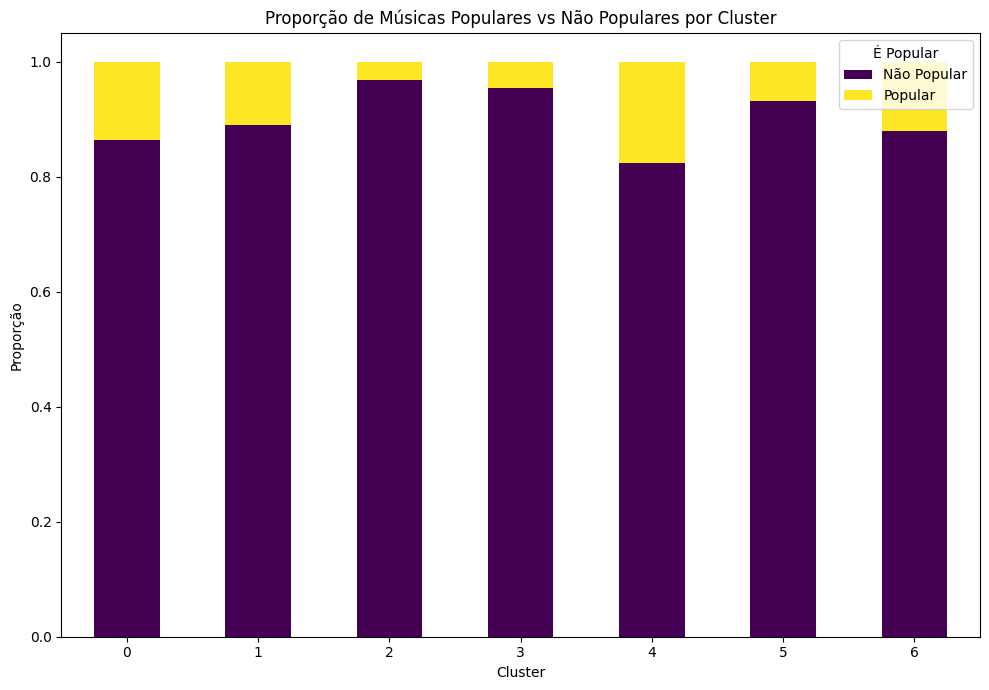

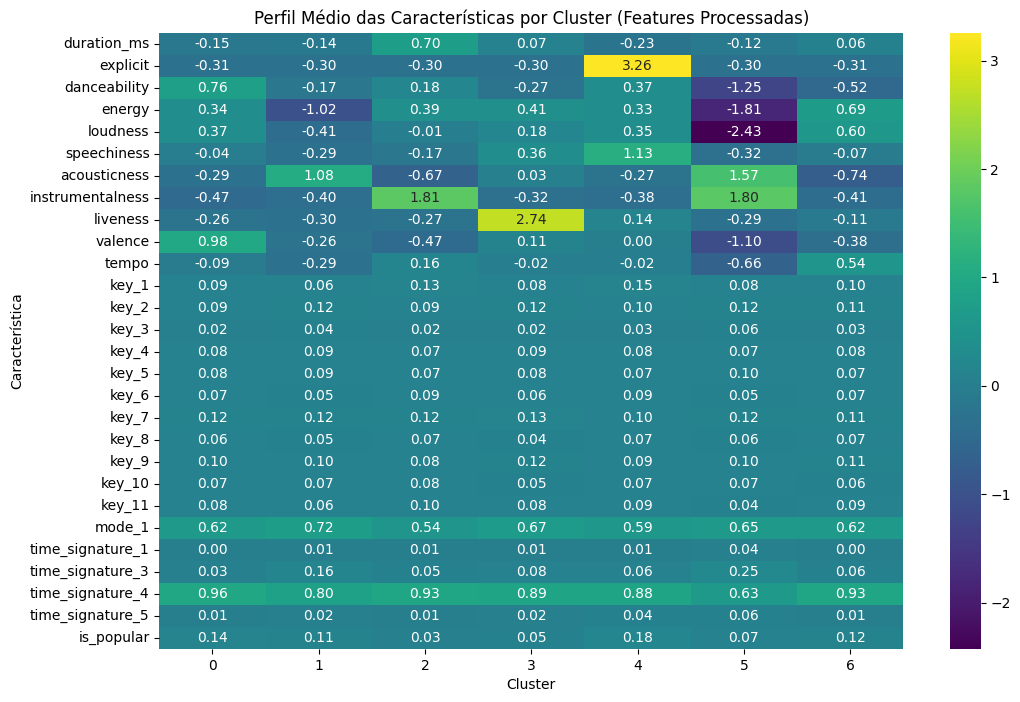

In [20]:
# Aprofundar a Análise de Clusterização

# Assumindo que X e y estão definidos a partir das células de pré-processamento
# Assumindo que optimal_k (número ótimo de clusters) foi determinado na célula jk6tSMxyTfDD

# 1. Aplicar K-Means com o número ótimo de clusters
from sklearn.cluster import KMeans

# Using the optimal_k determined in cell jk6tSMxyTfDD (assuming it's 7 based on previous output)
# It's better to get the value from the variable if it exists. Let's assume optimal_k is available.
# If not, we would need to re-run the elbow method cell or use the hardcoded value 7.
# For robustness, let's use the value from kneedle.knee if kneedle is available, otherwise default to 7.
try:
    optimal_k = int(kneedle.elbow)
    print(f"Using optimal_k from KneeLocator: {optimal_k}")
except NameError:
    optimal_k = 7
    print(f"Using hardcoded optimal_k: {optimal_k}")


kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X) # Fit on the complete preprocessed data X

# 2. Adicionar os rótulos dos clusters ao DataFrame original ou pré-processado
# Let's add to the preprocessed DataFrame X for analysis
X_clustered = X.copy()
X_clustered['cluster'] = clusters
X_clustered['is_popular'] = y # Add the target variable for analysis

# 3. Analisar as características médias de cada cluster
# We can group by cluster and calculate the mean of all features in X, plus popularity
cluster_profile = X_clustered.groupby('cluster').mean()

print("\nPerfil médio dos clusters (em features processadas):")
display(cluster_profile)

# 4. Analisar a distribuição de popularidade por cluster
popularity_by_cluster = X_clustered.groupby('cluster')['is_popular'].value_counts(normalize=True).unstack().fillna(0)

print("\nDistribuição de Popularidade (proporção) por Cluster:")
display(popularity_by_cluster)

# 5. Visualizar a distribuição de popularidade por cluster (usando um gráfico de barras empilhadas ou agrupadas)
popularity_by_cluster.plot(kind='bar', stacked=True, figsize=(10, 7), cmap='viridis')
plt.title('Proporção de Músicas Populares vs Não Populares por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporção')
plt.xticks(rotation=0)
plt.legend(title='É Popular', labels=['Não Popular', 'Popular'])
plt.tight_layout()
plt.show()


# Optional: Visualize mean feature values by cluster using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profile.T, annot=True, cmap='viridis', fmt='.2f')
plt.title('Perfil Médio das Características por Cluster (Features Processadas)')
plt.xlabel('Cluster')
plt.ylabel('Característica')
plt.show()